In [1]:
# =============================================================================
# Шаг 0: Подготовка и загрузка данных
# =============================================================================

# 1. Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import sklearn
import os

# Настройки для лучшего отображения
pd.set_option('display.max_columns', None) # Показывать все колонки
sns.set_style('darkgrid') # Стиль графиков

# 2. Загрузка данных
df = pd.read_csv('../data/01_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# 3. Первичный осмотр
print("Первые 5 строк датасета:")
display(df.head())

print("\nИнформация о типах данных и пропусках:")
df.info()

print("\nОсновные статистические показатели:")
display(df.describe())

Первые 5 строк датасета:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Информация о типах данных и пропусках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pa

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [2]:
# =============================================================================
# Шаг 1: Первичная очистка и преобразование данных
# =============================================================================

print("--- Начало Шага 1: Очистка данных ---")

# 1. Обработка колонки TotalCharges
# ------------------------------------
# Сейчас эта колонка имеет тип 'object', так как в ней есть пустые строки (' ').
# Преобразуем ее в числовой формат. Параметр errors='coerce' заменит все проблемные
# значения (наши пустые строки) на NaN (Not a Number), что позволит нам их легко найти.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Проверим, сколько пропущенных значений у нас появилось
print(f"Количество пропущенных значений в TotalCharges после преобразования: {df['TotalCharges'].isnull().sum()}")

# Мы видим 11 пропусков. Это очень мало по сравнению с общим объемом данных (~7000 строк).
# Самый простой и эффективный способ в данном случае - удалить строки с этими пропусками.
df.dropna(inplace=True)

# Сбросим индексы после удаления строк, чтобы они шли по порядку
df.reset_index(drop=True, inplace=True)

print(f"Количество пропущенных значений после удаления: {df['TotalCharges'].isnull().sum()}")


# 2. Обработка колонки SeniorCitizen
# -----------------------------------
# Сейчас эта колонка числовая (0 и 1). Для наглядности на графиках преобразуем ее
# в текстовые значения 'No' и 'Yes' с помощью метода .map().
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print(f"\nЗначения в колонке SeniorCitizen после преобразования: {df['SeniorCitizen'].unique()}")


# 3. Удаление ненужной колонки customerID
# -----------------------------------------
# Эта колонка является уникальным идентификатором и не несет полезной информации для модели.
df.drop('customerID', axis=1, inplace=True)
print("\nКолонка 'customerID' удалена.")


# 4. Итоговая проверка датасета после очистки
# ----------------------------------------------
print("\n--- Результат после Шага 1 ---")
print("Итоговая информация о датасете:")
df.info()

print("\nПервые 5 строк очищенного датасета:")
display(df.head())

--- Начало Шага 1: Очистка данных ---
Количество пропущенных значений в TotalCharges после преобразования: 11
Количество пропущенных значений после удаления: 0

Значения в колонке SeniorCitizen после преобразования: ['No' 'Yes']

Колонка 'customerID' удалена.

--- Результат после Шага 1 ---
Итоговая информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\2801038773.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, ax=axes[1], palette=['#66b3ff','#ff9999'], edgecolor='black')


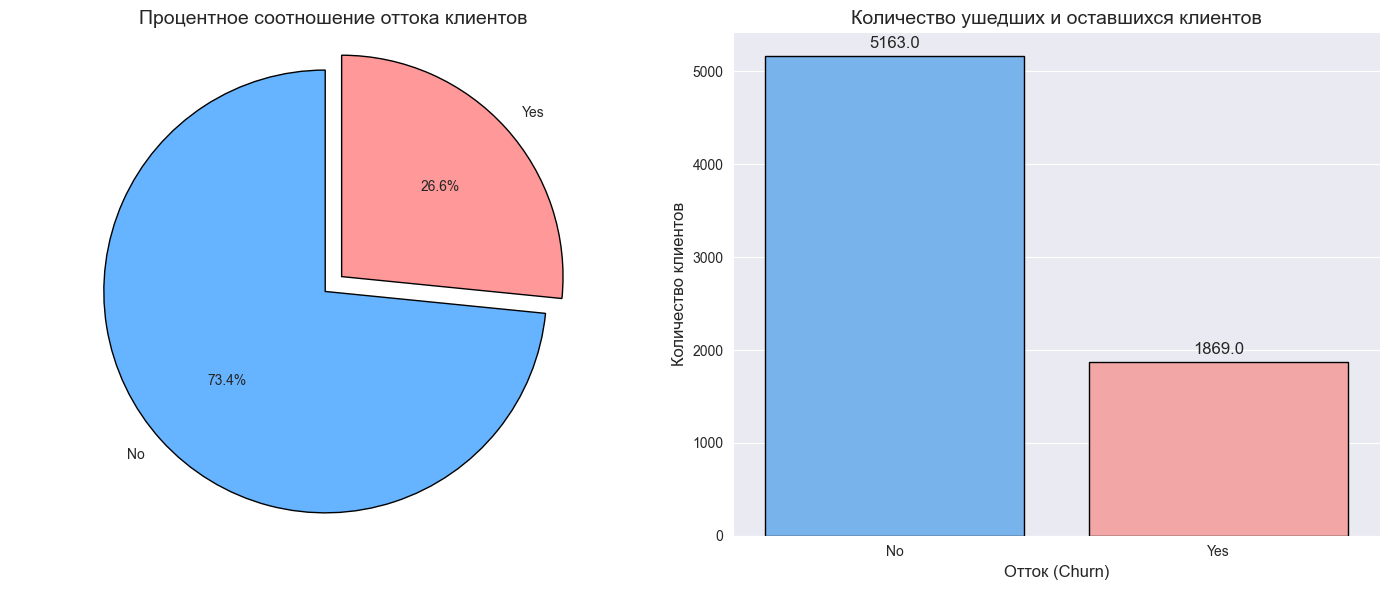

In [3]:
# =============================================================================
# Шаг 2: Разведочный анализ данных (EDA)
# 2.1 Анализ целевой переменной ('Churn')
# =============================================================================

# Создаем фигуру с двумя графиками рядом
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- График 1: Круговая диаграмма (Pie Chart) ---
churn_counts = df['Churn'].value_counts()
labels = churn_counts.index
sizes = churn_counts.values

axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['#66b3ff','#ff9999'], explode=(0.1, 0),
            wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[0].set_title('Процентное соотношение оттока клиентов', fontsize=14)
axes[0].axis('equal')  # Делает круглую диаграмму круглой

# --- График 2: Столбчатая диаграмма (Count Plot) ---
ax = sns.countplot(x='Churn', data=df, ax=axes[1], palette=['#66b3ff','#ff9999'], edgecolor='black')
axes[1].set_title('Количество ушедших и оставшихся клиентов', fontsize=14)
axes[1].set_xlabel('Отток (Churn)', fontsize=12)
axes[1].set_ylabel('Количество клиентов', fontsize=12)

# Добавляем подписи с точными числами над столбцами
for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=12)

plt.tight_layout() # Чтобы графики не накладывались друг на друга
plt.show()

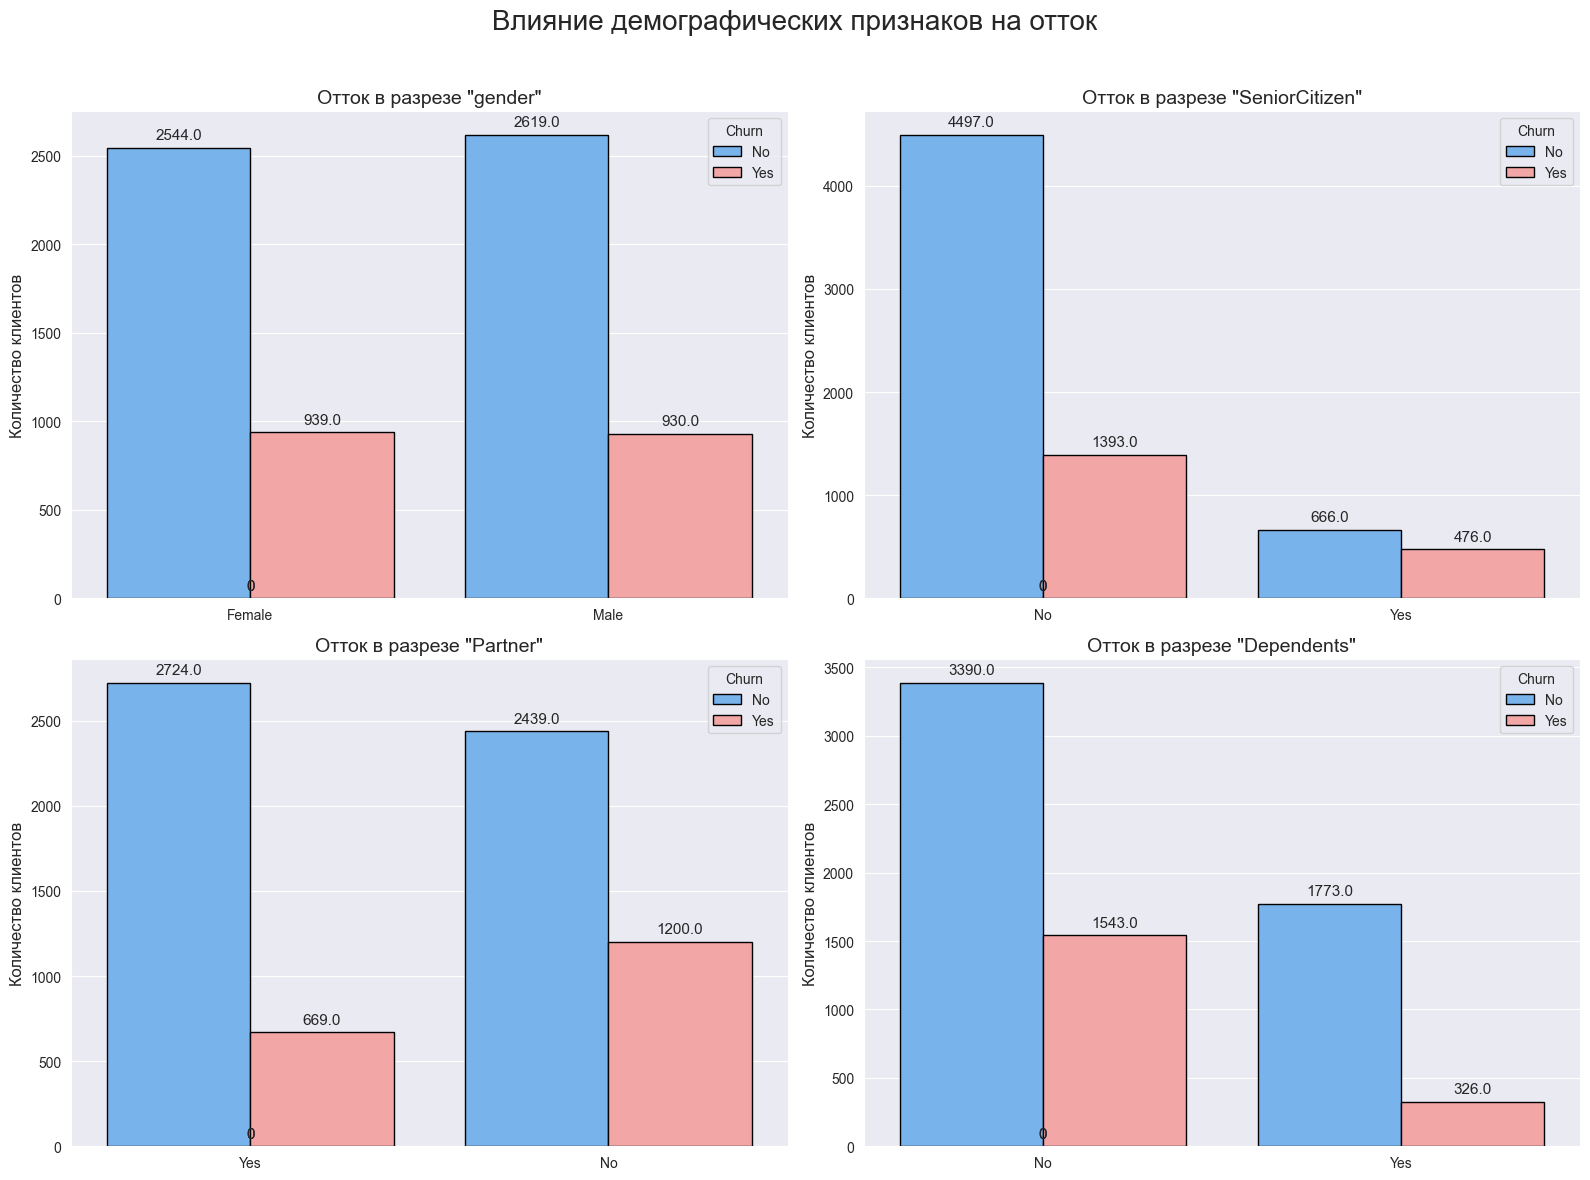

In [4]:
# =============================================================================
# Шаг 2: Разведочный анализ данных (EDA)
# 2.2 Анализ демографических признаков
# =============================================================================

# Определяем список признаков для анализа
demographic_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

# Создаем фигуру для сетки графиков 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Влияние демографических признаков на отток', fontsize=20)

# Преобразуем 2x2 массив осей в одномерный для удобства итерации
axes = axes.flatten()

# Проходим по каждому признаку и строим для него график
for i, feature in enumerate(demographic_features):
    ax = sns.countplot(x=feature, data=df, hue='Churn', ax=axes[i], palette=['#66b3ff','#ff9999'], edgecolor='black')
    axes[i].set_title(f'Отток в разрезе "{feature}"', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество клиентов', fontsize=12)

    # Добавляем подписи с точными числами над столбцами
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # Оставляем место для общего заголовка, если он нужен
plt.show()

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\1319611371.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha='right')


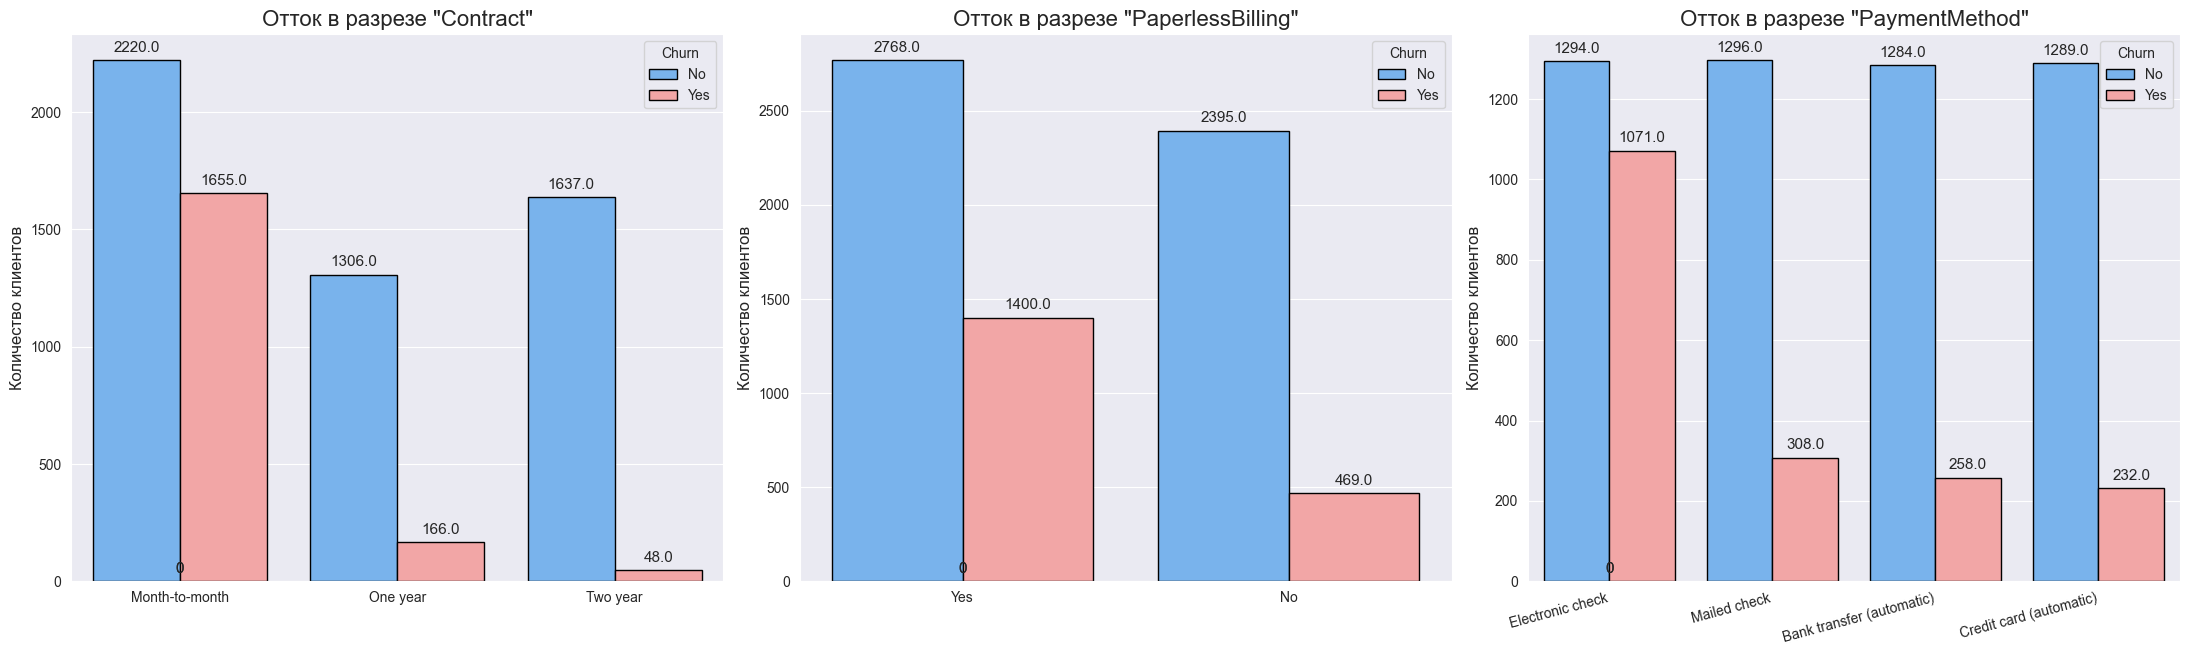

In [5]:
# =============================================================================
# Шаг 2: Разведочный анализ данных (EDA)
# 2.3 Анализ признаков, связанных с контрактом и оплатой
# =============================================================================

# Определяем список признаков для анализа
contract_payment_features = ['Contract', 'PaperlessBilling', 'PaymentMethod']

# Создаем фигуру для 3 графиков в ряд
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
# fig.suptitle('Влияние контракта и оплаты на отток', fontsize=20)

# Проходим по каждому признаку и строим для него график
for i, feature in enumerate(contract_payment_features):
    ax = sns.countplot(x=feature, data=df, hue='Churn', ax=axes[i], palette=['#66b3ff','#ff9999'], edgecolor='black')
    axes[i].set_title(f'Отток в разрезе "{feature}"', fontsize=16)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество клиентов', fontsize=12)

    # Добавляем подписи с точными числами
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=11)

# Поворачиваем подписи на оси X для последнего графика, чтобы они не накладывались
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\61626923.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=10, ha='right')
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\61626923.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=10, ha='right')
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\61626923.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=10, ha='right')
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\61626923.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after

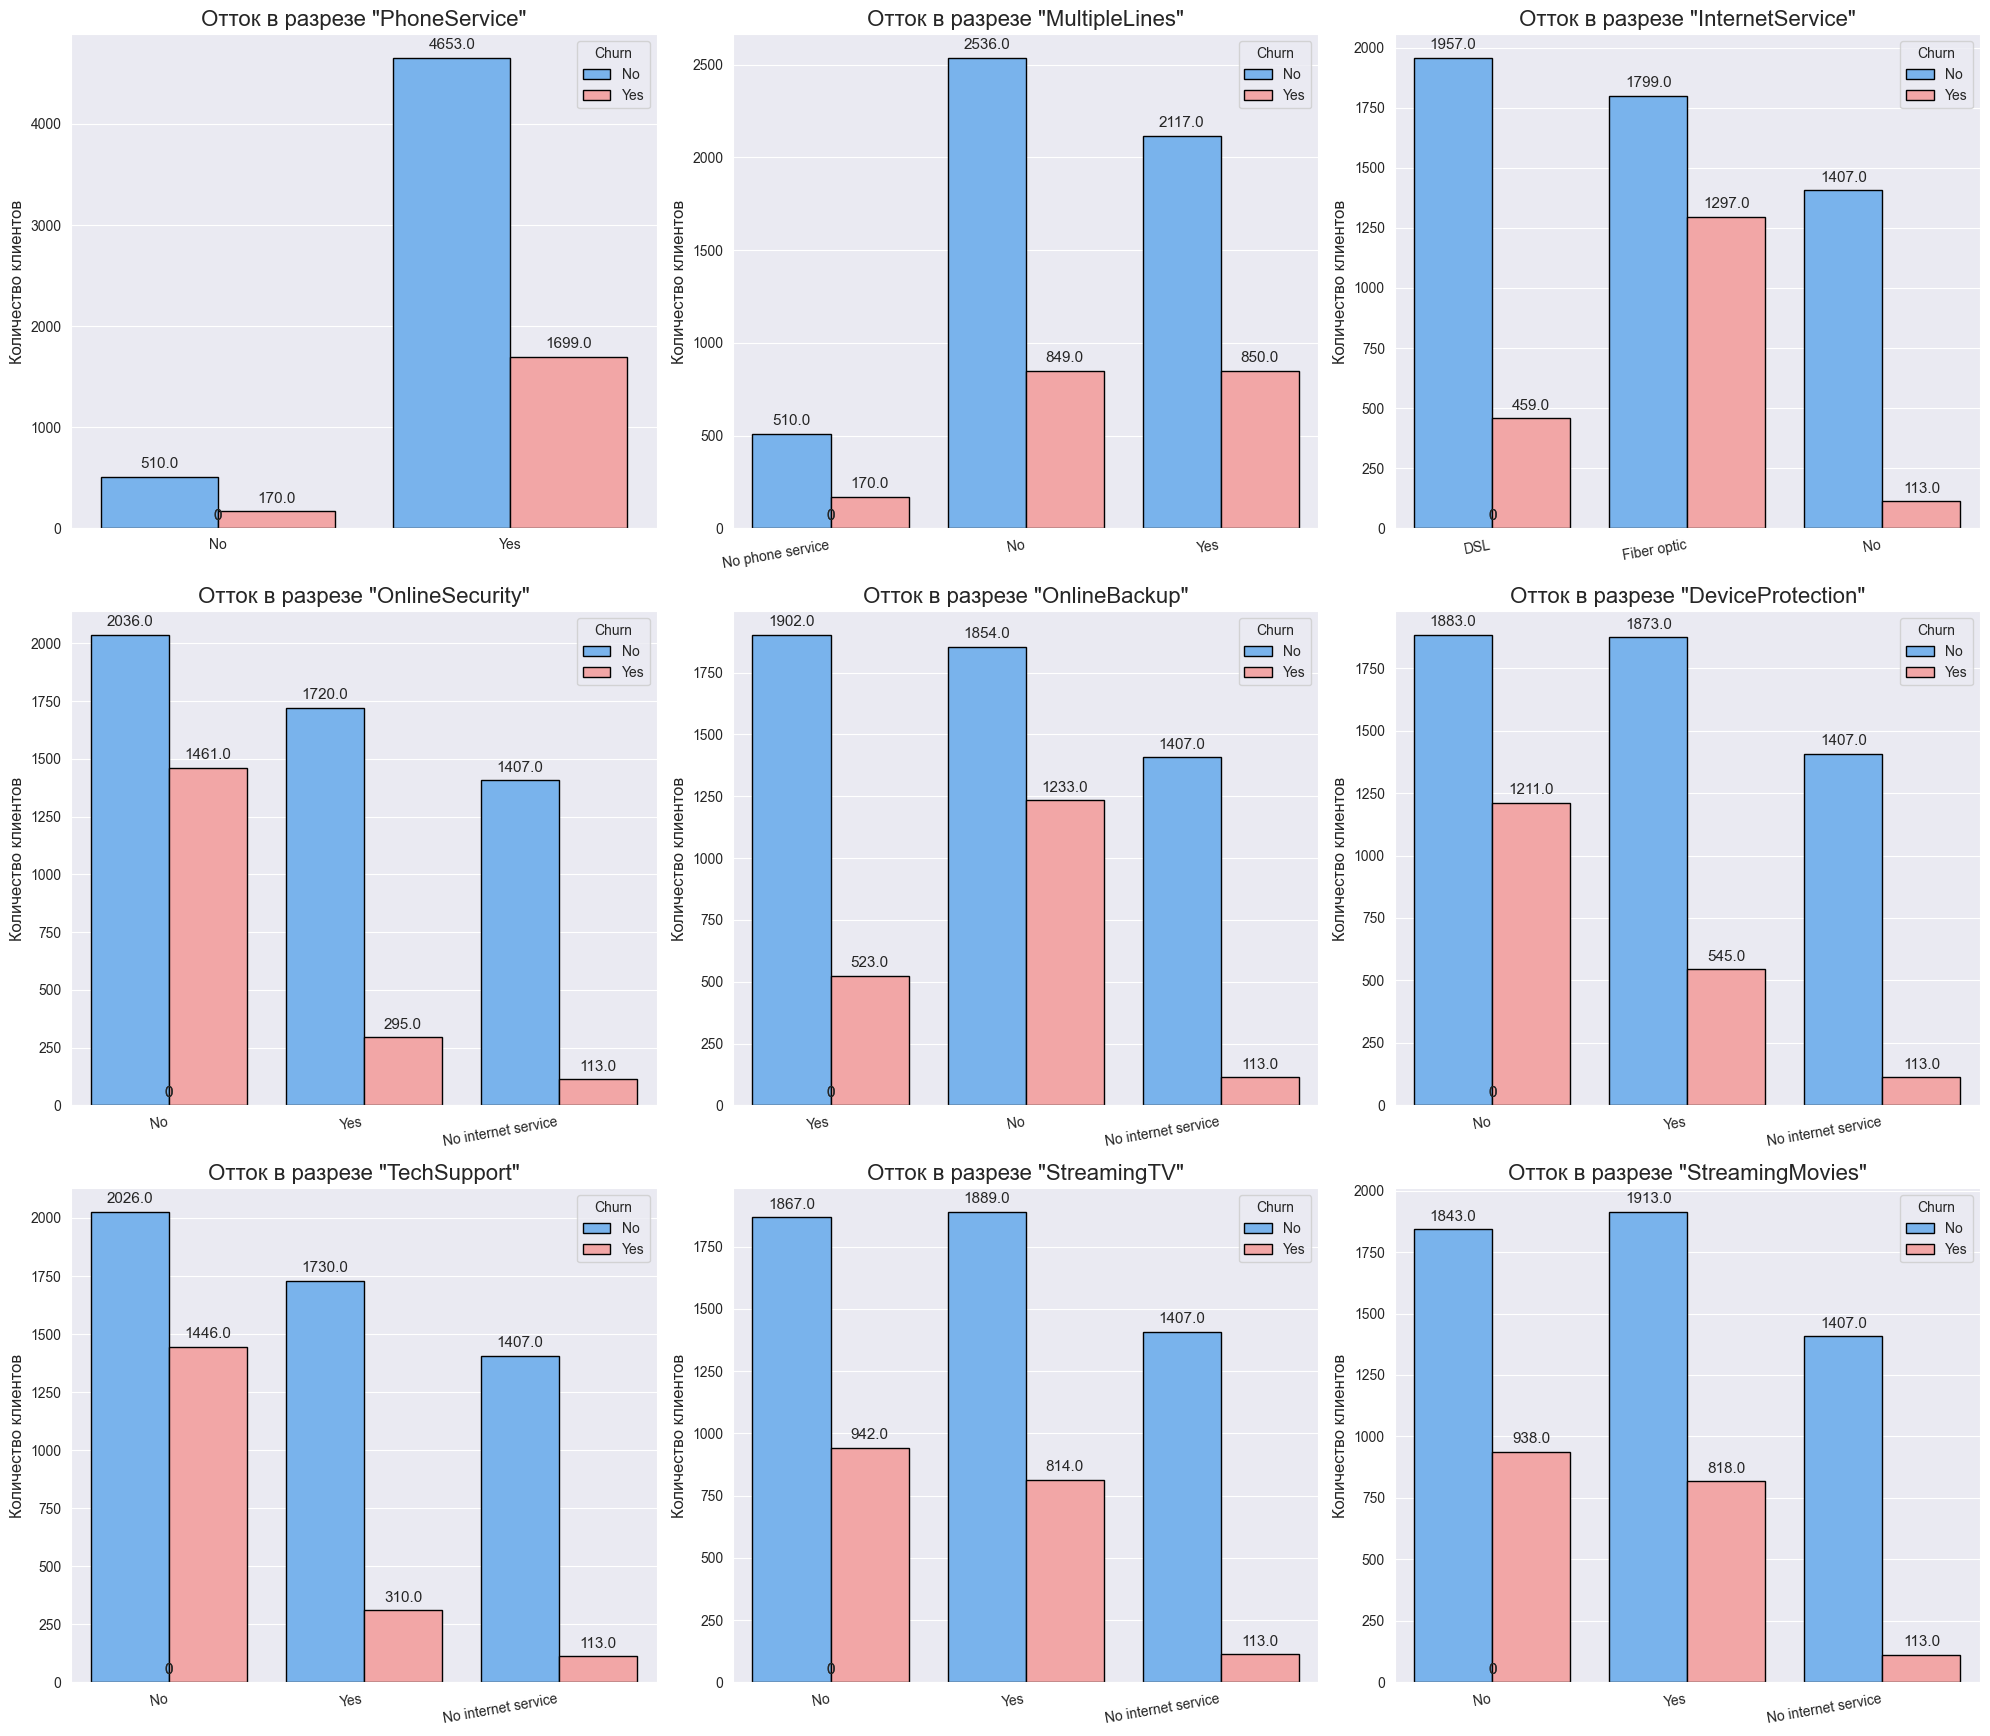

In [6]:
# =============================================================================
# Шаг 2: Разведочный анализ данных (EDA)
# 2.4 Анализ признаков, связанных с услугами
# =============================================================================

# Определяем список всех признаков, связанных с услугами
service_features = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Создаем фигуру для сетки графиков 3x3
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
# fig.suptitle('Влияние подключенных услуг на отток', fontsize=22)

# Преобразуем 2D массив осей в 1D для удобства итерации
axes = axes.flatten()

# Проходим по каждому признаку и строим для него график
for i, feature in enumerate(service_features):
    ax = sns.countplot(x=feature, data=df, hue='Churn', ax=axes[i], palette=['#66b3ff','#ff9999'], edgecolor='black')
    axes[i].set_title(f'Отток в разрезе "{feature}"', fontsize=16)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Количество клиентов', fontsize=12)

    # Поворачиваем подписи, если они длинные
    if len(df[feature].unique()) > 2:
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=10, ha='right')

    # Добавляем подписи с точными числами
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\3580353670.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 'Yes'][feature], ax=axes[i], color='red', shade=True, label='Churn: Yes', cut=0)
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\3580353670.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 'No'][feature], ax=axes[i], color='blue', shade=True, label='Churn: No', cut=0)
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_15144\3580353670.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Churn'] == 'Yes'][feature], ax=axes[i], color='red', shade=Tr

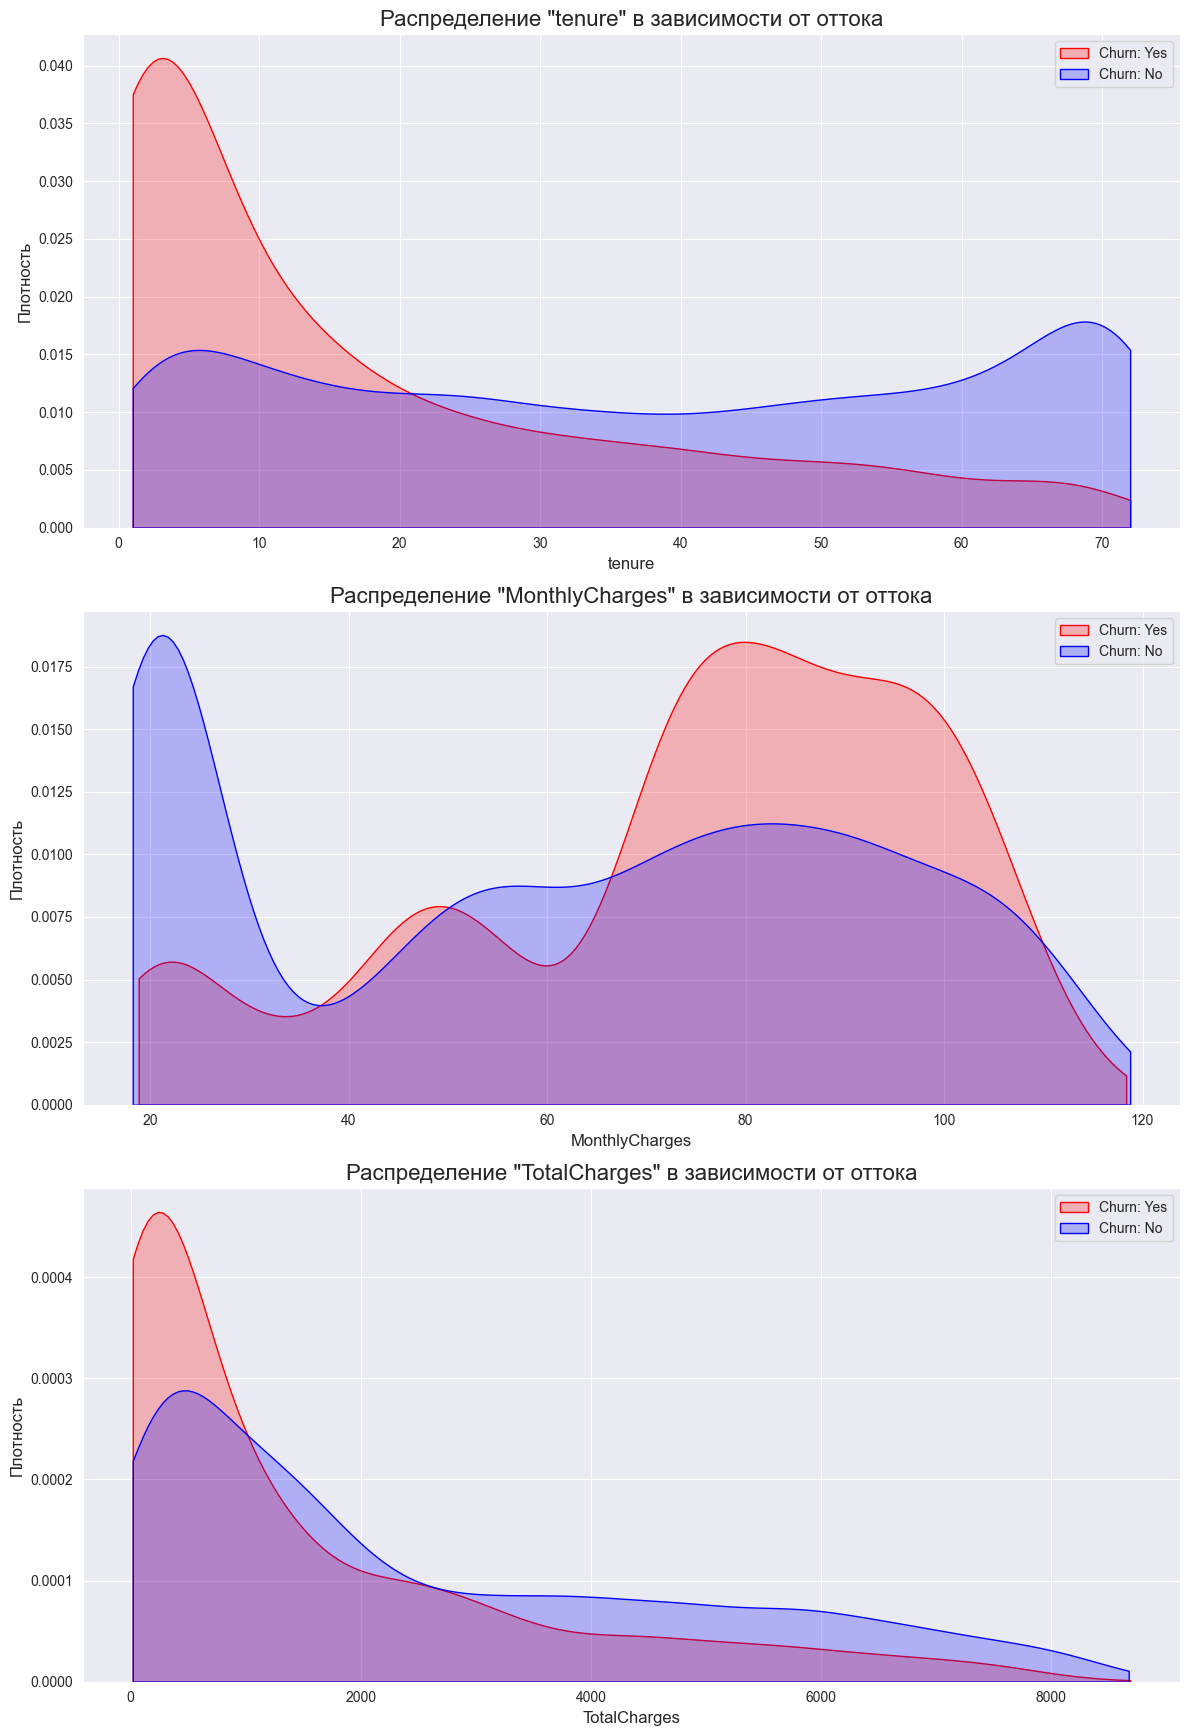

In [7]:
# =============================================================================
# Шаг 2: Разведочный анализ данных (EDA)
# 2.5 Анализ числовых признаков
# =============================================================================

# Определяем список числовых признаков
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Создаем фигуру для 3 графиков один под другим
fig, axes = plt.subplots(3, 1, figsize=(12, 18))
# fig.suptitle('Распределение числовых признаков в зависимости от оттока', fontsize=20)

# Проходим по каждому признаку и строим для него график
for i, feature in enumerate(numerical_features):
    # График для ушедших клиентов
    sns.kdeplot(df[df['Churn'] == 'Yes'][feature], ax=axes[i], color='red', shade=True, label='Churn: Yes', cut=0)
    # График для оставшихся клиентов
    sns.kdeplot(df[df['Churn'] == 'No'][feature], ax=axes[i], color='blue', shade=True, label='Churn: No', cut=0)

    axes[i].set_title(f'Распределение "{feature}" в зависимости от оттока', fontsize=16)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Плотность', fontsize=12)
    axes[i].legend()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [8]:
# =============================================================================
# Шаг 3: Предобработка данных для моделей
# =============================================================================
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Создадим копию нашего датафрейма, чтобы не изменять исходный df,
# который мы использовали для EDA
df_processed = df.copy()

# 1. Кодирование бинарных категориальных признаков
# ------------------------------------------------
# Признаки, у которых только два уникальных значения (кроме Churn),
# можно легко закодировать в 0 и 1 с помощью LabelEncoder.
binary_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])

# Также закодируем целевую переменную 'Churn'
df_processed['Churn'] = df_processed['Churn'].map({'No': 0, 'Yes': 1})

# 2. Кодирование категориальных признаков с несколькими значениями (One-Hot Encoding)
# ---------------------------------------------------------------------------------
# Для признаков с более чем двумя категориями используем pd.get_dummies().
# Это создаст новые столбцы для каждой категории.
# drop_first=True удаляет одну из категорий, чтобы избежать мультиколлинеарности (избыточности).
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
                  'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_processed = pd.get_dummies(df_processed, columns=multi_cat_cols, drop_first=True)


# 3. Масштабирование числовых признаков
# ------------------------------------
# Используем StandardScaler, который приводит данные к среднему 0 и стандартному отклонению 1.
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()

df_processed[numerical_features] = scaler.fit_transform(df_processed[numerical_features])


# 4. Итоговый результат
# ---------------------
print("--- Результат после Шага 3 ---")
print("Размерность обработанного датасета:", df_processed.shape)
print("\nПервые 5 строк обработанного датасета:")
display(df_processed.head())

print("\nПроверка типов данных после всех преобразований:")
df_processed.info()

--- Результат после Шага 3 ---
Размерность обработанного датасета: (7032, 31)

Первые 5 строк обработанного датасета:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False



Проверка типов данных после всех преобразований:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   float64
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  MultipleLines_No phone

In [9]:
# 1. Указываем имя папки, куда хотим сохранить файл
output_dir = '../data/02_processed' # или 'processed_data', 'output' - как вам удобнее

# 2. Создаем эту папку, если она еще не существует
#    exist_ok=True означает, что код не выдаст ошибку, если папка уже есть
os.makedirs(output_dir, exist_ok=True)

# 3. Формируем полный путь к файлу
output_path = os.path.join(output_dir, 'churn_data_processed.csv')

# 4. Сохраняем датафрейм
df_processed.to_csv(output_path, index=False)

print(f"Обработанный датасет успешно сохранен по пути: {output_path}")

Обработанный датасет успешно сохранен по пути: ../data/02_processed\churn_data_processed.csv
